In [1]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

conn   = sqlite3.connect('olist_database.db')
engine = create_engine('sqlite:///olist_database.db')

print("Connected to olist_database.db ✓")

Connected to olist_database.db ✓


In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
customers.to_sql('customers', conn, if_exists='replace', index=False)
print("customers loaded ✓ —", len(customers), "rows")

customers loaded ✓ — 99441 rows


In [3]:
avg_spend_query = '''
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id)      AS total_orders,
        ROUND(SUM(oi.price), 2)         AS total_spend,
        ROUND(AVG(oi.price), 2)         AS avg_item_price,
        MIN(o.order_purchase_timestamp) AS first_order_date,
        MAX(o.order_purchase_timestamp) AS last_order_date
    FROM orders o
    JOIN order_items oi ON o.order_id    = oi.order_id
    JOIN customers c    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    ORDER BY total_spend DESC
'''

customer_spend = pd.read_sql_query(avg_spend_query, conn)

overall_avg = customer_spend['total_spend'].mean().round(2)
threshold   = (overall_avg * 3).round(2)

print(f"Total unique customers     : {len(customer_spend):,}")
print(f"Average spend per customer : BRL {overall_avg}")
print(f"3x threshold               : BRL {threshold}")

Total unique customers     : 93,358
Average spend per customer : BRL 141.62
3x threshold               : BRL 424.86


In [4]:
high_value_query = f'''
    WITH customer_totals AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            c.customer_city,
            COUNT(DISTINCT o.order_id)      AS total_orders,
            ROUND(SUM(oi.price), 2)         AS total_spend,
            ROUND(AVG(oi.price), 2)         AS avg_item_price,
            MIN(o.order_purchase_timestamp) AS first_order_date,
            MAX(o.order_purchase_timestamp) AS last_order_date
        FROM orders o
        JOIN order_items oi ON o.order_id    = oi.order_id
        JOIN customers c    ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, c.customer_state, c.customer_city
    ),
    overall_avg AS (
        SELECT ROUND(AVG(total_spend), 2) AS avg_spend
        FROM customer_totals
    )
    SELECT
        ct.*,
        oa.avg_spend                                    AS platform_avg_spend,
        ROUND(oa.avg_spend * 3, 2)                      AS threshold_3x,
        ROUND(ct.total_spend / oa.avg_spend, 2)         AS spend_multiplier
    FROM customer_totals ct
    CROSS JOIN overall_avg oa
    WHERE ct.total_spend >= oa.avg_spend * 3
    ORDER BY ct.total_spend DESC
'''

high_value_df = pd.read_sql_query(high_value_query, conn)

print(f"High value customers identified : {len(high_value_df):,}")
print(f"Platform average spend          : BRL {high_value_df['platform_avg_spend'].iloc[0]}")
print(f"3x threshold                    : BRL {high_value_df['threshold_3x'].iloc[0]}")
print(f"\nTop 10 highest spenders:")
print(high_value_df[['customer_unique_id','customer_state','total_orders',
                      'total_spend','spend_multiplier']].head(10).to_string(index=False))

High value customers identified : 4,585
Platform average spend          : BRL 141.45
3x threshold                    : BRL 424.35

Top 10 highest spenders:
              customer_unique_id customer_state  total_orders  total_spend  spend_multiplier
0a0a92112bd4c708ca5fde585afaa872             RJ             1      13440.0             95.02
da122df9eeddfedc1dc1f5349a1a690c             RJ             2       7388.0             52.23
763c8b1c9c68a0229c42c9fc6f662b93             ES             1       7160.0             50.62
dc4802a71eae9be1dd28f5d788ceb526             MS             1       6735.0             47.61
459bef486812aa25204be022145caa62             ES             1       6729.0             47.57
ff4159b92c40ebe40454e3e6a7c35ed6             SP             1       6499.0             45.95
4007669dec559734d6f53e029e360987             MG             1       5934.6             41.96
eebb5dda148d3893cdaf5b5ca3040ccb             SP             1       4690.0             33.16
48e1ac1

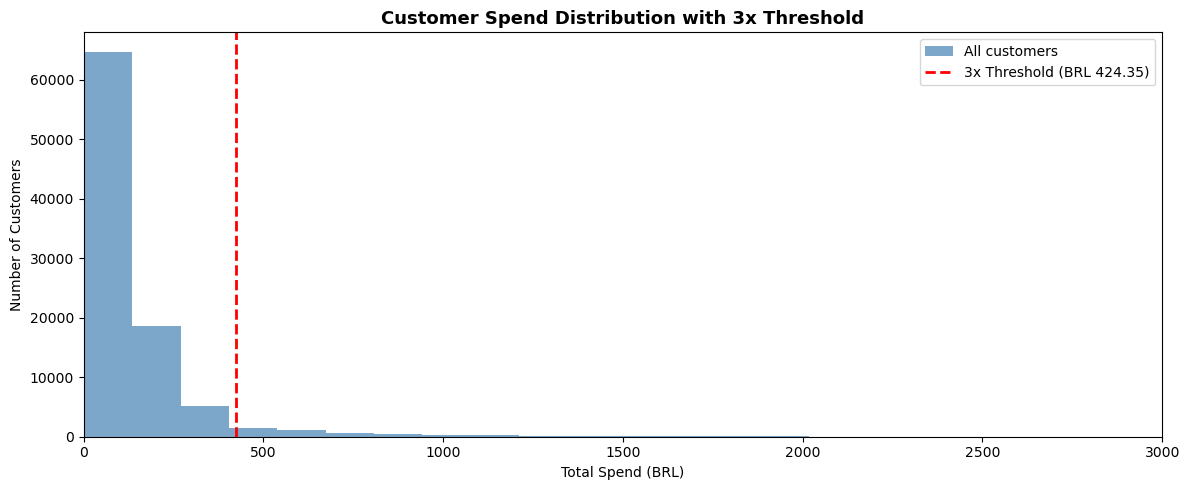

Customers below threshold : 88,768
Customers above threshold : 4,585


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(customer_spend['total_spend'], bins=100, 
        color='steelblue', alpha=0.7, label='All customers')

threshold_val = high_value_df['threshold_3x'].iloc[0]
ax.axvline(x=threshold_val, color='red', linewidth=2, 
           linestyle='--', label=f'3x Threshold (BRL {threshold_val})')

ax.set_title('Customer Spend Distribution with 3x Threshold', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Spend (BRL)')
ax.set_ylabel('Number of Customers')
ax.set_xlim(0, 3000)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Customers below threshold : {len(customer_spend[customer_spend['total_spend'] < threshold_val]):,}")
print(f"Customers above threshold : {len(high_value_df):,}")

In [6]:
repeat_query = '''
    SELECT
        c.customer_unique_id,
        c.customer_state,
        c.customer_city,
        COUNT(DISTINCT o.order_id)      AS total_orders,
        ROUND(SUM(oi.price), 2)         AS total_spend,
        MIN(o.order_purchase_timestamp) AS first_order_date,
        MAX(o.order_purchase_timestamp) AS last_order_date
    FROM orders o
    JOIN order_items oi ON o.order_id    = oi.order_id
    JOIN customers c    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id, c.customer_state, c.customer_city
    HAVING COUNT(DISTINCT o.order_id) >= 2
    ORDER BY total_orders DESC, total_spend DESC
'''

repeat_df = pd.read_sql_query(repeat_query, conn)

print(f"Total repeat purchasers (2+ orders) : {len(repeat_df):,}")
print(f"Max orders by one customer          : {repeat_df['total_orders'].max()}")
print(f"\nOrder frequency breakdown:")
print(repeat_df['total_orders'].value_counts().sort_index().head(10))

Total repeat purchasers (2+ orders) : 2,699
Max orders by one customer          : 15

Order frequency breakdown:
total_orders
2     2480
3      174
4       26
5        9
6        5
7        3
9        1
15       1
Name: count, dtype: int64


In [7]:
vip_query = f'''
    WITH customer_totals AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            c.customer_city,
            COUNT(DISTINCT o.order_id)          AS total_orders,
            ROUND(SUM(oi.price), 2)             AS total_spend,
            ROUND(AVG(oi.price), 2)             AS avg_item_price,
            MIN(o.order_purchase_timestamp)     AS first_order_date,
            MAX(o.order_purchase_timestamp)     AS last_order_date
        FROM orders o
        JOIN order_items oi ON o.order_id    = oi.order_id
        JOIN customers c    ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, c.customer_state, c.customer_city
    ),
    overall_avg AS (
        SELECT ROUND(AVG(total_spend), 2) AS avg_spend
        FROM customer_totals
    )
    SELECT
        ct.customer_unique_id,
        ct.customer_state,
        ct.customer_city,
        ct.total_orders,
        ct.total_spend,
        ct.avg_item_price,
        ct.first_order_date,
        ct.last_order_date,
        ROUND(ct.total_spend / oa.avg_spend, 2)     AS spend_multiplier,
        CASE
            WHEN ct.total_orders >= 5 THEN 'PLATINUM'
            WHEN ct.total_orders >= 3 THEN 'GOLD'
            ELSE                           'SILVER'
        END                                         AS vip_tier
    FROM customer_totals ct
    CROSS JOIN overall_avg oa
    WHERE
        ct.total_spend  >= oa.avg_spend * 3
        AND ct.total_orders >= 2
    ORDER BY ct.total_spend DESC
'''

vip_df = pd.read_sql_query(vip_query, conn)

print(f"Total VIP customers : {len(vip_df):,}")
print(f"\nVIP tier breakdown  :")
print(vip_df['vip_tier'].value_counts())
print(f"\nTop 10 VIP customers:")
print(vip_df[['customer_unique_id','customer_state','total_orders',
              'total_spend','spend_multiplier','vip_tier']].head(10).to_string(index=False))

Total VIP customers : 380

VIP tier breakdown  :
vip_tier
SILVER      302
GOLD         64
PLATINUM     14
Name: count, dtype: int64

Top 10 VIP customers:
              customer_unique_id customer_state  total_orders  total_spend  spend_multiplier vip_tier
da122df9eeddfedc1dc1f5349a1a690c             RJ             2      7388.00             52.23   SILVER
c8460e4251689ba205045f3ea17884a1             RS             4      4080.00             28.84     GOLD
59d66d72939bc9497e19d89c61a96d5f             SP             2      3459.00             24.45   SILVER
d77aa95864ae5b42160937615628723a             BA             2      2400.00             16.97   SILVER
7b0eaf68a16e4808e5388c67345033c9             SP             2      2238.42             15.82   SILVER
86df00dc5fd68f4dd5d5945ca19f3ed6             RS             3      2200.00             15.55     GOLD
6ddbc64bd04d40f7768ff088d94cbeb8             SP             2      2108.00             14.90   SILVER
73601b1eec55943e90ce8d61253d5

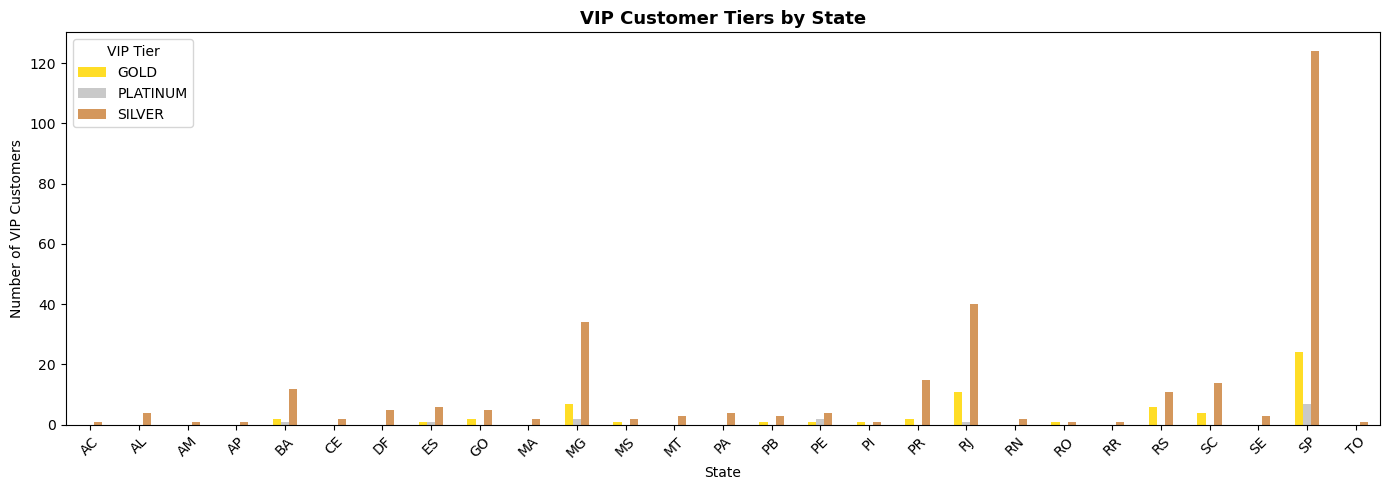

In [8]:
tier_state = vip_df.groupby(['customer_state','vip_tier']).size().unstack(fill_value=0)

tier_state.plot(kind='bar', figsize=(14,5), 
                color=['gold','silver','peru'], alpha=0.85)

plt.title('VIP Customer Tiers by State', fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of VIP Customers')
plt.legend(title='VIP Tier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
retention_query = f'''
    WITH customer_totals AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            c.customer_city,
            COUNT(DISTINCT o.order_id)          AS total_orders,
            ROUND(SUM(oi.price), 2)             AS total_spend,
            ROUND(AVG(oi.price), 2)             AS avg_item_price,
            MIN(o.order_purchase_timestamp)     AS first_order_date,
            MAX(o.order_purchase_timestamp)     AS last_order_date,
            ROUND(JULIANDAY(MAX(o.order_purchase_timestamp)) -
                  JULIANDAY(MIN(o.order_purchase_timestamp)), 0)
                                                AS customer_lifespan_days
        FROM orders o
        JOIN order_items oi ON o.order_id    = oi.order_id
        JOIN customers c    ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, c.customer_state, c.customer_city
    ),
    overall_avg AS (
        SELECT ROUND(AVG(total_spend), 2) AS avg_spend
        FROM customer_totals
    )
    SELECT
        ct.customer_unique_id,
        ct.customer_state,
        ct.customer_city,
        ct.total_orders,
        ct.total_spend,
        ct.avg_item_price,
        ct.first_order_date,
        ct.last_order_date,
        ct.customer_lifespan_days,
        ROUND(ct.total_spend / oa.avg_spend, 2)     AS spend_multiplier,
        CASE
            WHEN ct.total_orders >= 5 THEN 'PLATINUM'
            WHEN ct.total_orders >= 3 THEN 'GOLD'
            WHEN ct.total_orders >= 2 THEN 'SILVER'
            ELSE                           'HIGH_VALUE_SINGLE'
        END                                         AS segment
    FROM customer_totals ct
    CROSS JOIN overall_avg oa
    WHERE ct.total_spend >= oa.avg_spend * 3
    ORDER BY ct.total_spend DESC
'''

retention_list = pd.read_sql_query(retention_query, conn)

print(f"Total customers in retention list : {len(retention_list):,}")
print(f"\nSegment breakdown:")
print(retention_list['segment'].value_counts())
print(f"\nFull retention list preview:")
print(retention_list.head(15).to_string(index=False))